In [ ]:
#Drive connect
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

root = "/content/drive/MyDrive/Alvi/MLMI-2024"
for path, dirs, files in os.walk(root):
    print(path, len(files))
    break  # just show top level

/content/drive/MyDrive/Alvi/MLMI-2024 0


In [ ]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, learning_curve, validation_curve
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.base import clone
from sklearn.metrics import roc_curve, auc




In [ ]:
#processing and Feature Extract
DATASET_ROOT = "/content/drive/MyDrive/Alvi/MLMI-2024"

IMG_SIZE = (64, 64)
Random_State = 42

X = []
y = []

label_map = {
    "Aedes aegypti": 0,
    "Culex quinquefasciatus": 1
}

for class_name, label in label_map.items():
    siphon_dir = os.path.join(DATASET_ROOT, class_name, "siphon")

    for img_name in os.listdir(siphon_dir):
        img_path = os.path.join(siphon_dir, img_name)

        img = Image.open(img_path).convert("L")  # grayscale
        img = img.resize(IMG_SIZE)
        img = np.array(img).flatten()            # raw pixels

        X.append(img)
        y.append(label)


X = np.array(X)
y = np.array(y)

print("Total samples:", X.shape[0])
print("Feature dimension:", X.shape[1])



Total samples: 200
Feature dimension: 4096


In [ ]:
#Train-Test Split(70-30) 15 Val 15 Test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=Random_State,
    stratify=y
)

# 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=Random_State,
    stratify=y_temp
)

print("Train:", len(y_train))
print("Val:", len(y_val))
print("Test:", len(y_test))


Train: 140
Val: 30
Test: 30


In [ ]:
#Include Models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ]),

    "SVM (Linear)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear"))
    ]),

    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf"))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=Random_State
    )
}


In [ ]:
#Without Cross-validation
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-Score": f1_score(y_val, y_pred)
    })
print("/n"+ "="*60)
print("Training Validation")
print("="*60)
results_df = pd.DataFrame(results)
results_df


/n============================================================
Training Validation


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.933333,0.933333,0.933333,0.933333
1,SVM (Linear),0.966667,0.937500,1.000000,0.967742
2,SVM (RBF),0.900000,0.928571,0.866667,0.896552
3,Random Forest,0.833333,0.812500,0.866667,0.838710


In [ ]:
#Testing Models
test_results = []
for name, model in models.items():

    y_test_pred = model.predict(X_test)

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "F1-Score": f1_score(y_test, y_test_pred)})
print("/n"+ "="*60)
print("Testing")
print("="*60)
test_results_df = pd.DataFrame(test_results)
test_results_df

/n============================================================
Testing


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,1.000000,1.0,1.000000,1.000000
1,SVM (Linear),1.000000,1.0,1.000000,1.000000
2,SVM (RBF),0.966667,1.0,0.933333,0.965517
3,Random Forest,1.000000,1.0,1.000000,1.000000


In [ ]:
def plot_multiple_rocs(roc_data, title="ROC Curves (Cross-Validated)"):
    plt.figure()

    for model_name, (y_true, y_score) in roc_data.items():
        fpr, tpr, _ = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()


In [ ]:
#5-Fold Cross validation
N_SPLITS = 5
skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

In [ ]:
#Cross validation not with curves
cv_results = []

for model_name, model in models.items():
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        fold_accuracies.append(accuracy_score(y_test, y_pred))
        fold_precisions.append(precision_score(y_test, y_pred))
        fold_recalls.append(recall_score(y_test, y_pred))
        fold_f1s.append(f1_score(y_test, y_pred))

    cv_results.append({
        "Model": model_name,
        "Accuracy (mean)": np.mean(fold_accuracies),
        "Accuracy (std)": np.std(fold_accuracies),
        "Precision (mean)": np.mean(fold_precisions),
        "Recall (mean)": np.mean(fold_recalls),
        "F1 (mean)": np.mean(fold_f1s)
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

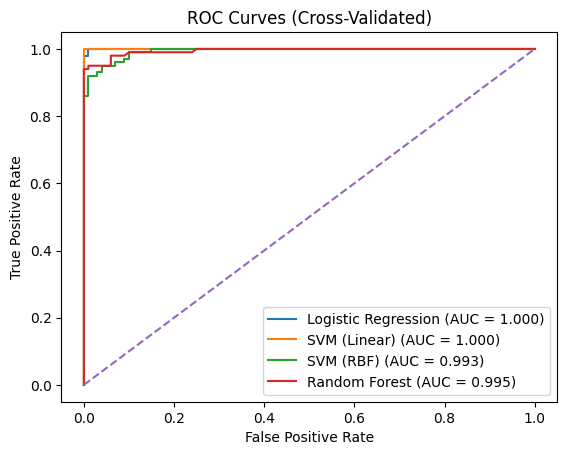

In [ ]:
#Models trained using Cross-validation
cv_results = []
roc_data = {}   # <-- store ROC inputs per model

for model_name, model in models.items():
    fold_accuracies = []
    fold_precisions = []
    fold_recalls = []
    fold_f1s = []

    y_true_all = []
    y_score_all = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model_clone = clone(model)
        model_clone.fit(X_train, y_train)

        y_pred = model_clone.predict(X_test)

        # ROC needs probabilities (or decision scores)
        if hasattr(model_clone, "predict_proba"):
            y_score = model_clone.predict_proba(X_test)[:, 1]
        else:
            y_score = model_clone.decision_function(X_test)

        # metrics
        fold_accuracies.append(accuracy_score(y_test, y_pred))
        fold_precisions.append(precision_score(y_test, y_pred))
        fold_recalls.append(recall_score(y_test, y_pred))
        fold_f1s.append(f1_score(y_test, y_pred))

        # store for ROC
        y_true_all.extend(y_test)
        y_score_all.extend(y_score)

    cv_results.append({
        "Model": model_name,
        "Accuracy (mean)": np.mean(fold_accuracies),
        "Accuracy (std)": np.std(fold_accuracies),
        "Precision (mean)": np.mean(fold_precisions),
        "Recall (mean)": np.mean(fold_recalls),
        "F1 (mean)": np.mean(fold_f1s)
    })

    roc_data[model_name] = (np.array(y_true_all), np.array(y_score_all))

cv_results_df = pd.DataFrame(cv_results)
cv_results_df
plot_multiple_rocs(roc_data)